# DS1 — Data Engineering & Preparation  
## CentSaver: Smart Expense Awareness System  
**Coding Camp 2026 | CC26-PRU458**

---
**Dikerjakan oleh:** Raihan Ikram Maulana (Data Scientist 1 — Data Engineering & Preparation)
---

## 🎯 Tujuan Notebook

Notebook ini bertujuan untuk membangun dataset yang bersih, terstruktur, dan **merepresentasikan realita perilaku finansial pengguna** untuk digunakan pada:

- **Exploratory Data Analysis (DS2)**
- **Pelatihan Model Deep Learning** (memastikan model kebal terhadap *data leakage* dan mampu menggeneralisasi pola pengeluaran dengan baik)

Seluruh proses dilakukan secara *end-to-end* mulai dari pengumpulan data mentah, injeksi data kontekstual, hingga menghasilkan dataset final.

---

## 🔧 Pipeline yang Dikerjakan

1. **Data Loading & Assessment** Memuat dataset mentah dan mengevaluasi kualitas data (struktur, *missing values*, distribusi awal).
2. **Data Cleaning & Preprocessing** Membersihkan data dari *noise*, duplikasi, dan inkonsistensi format.
3. **Standardisasi & Feature Engineering** Menyamakan format nominal serta membuat fitur turunan berbasis waktu seperti hari (`day_of_week`), bulan (`month`), dan penanda akhir pekan (`is_weekend`).
4. **Pembuatan Data Sintetis (Konteks Indonesia)** Menambahkan data tambahan untuk memperkaya variasi transaksi lokal menggunakan *pseudo-labeling* sebagai *template* awal.
5. **Merge Dataset** Menggabungkan seluruh dataset eksternal dan sintetis menjadi satu *dataframe* terpusat (`df_master`).
6. **Global Relabeling (Probabilistic & Contextual) 🌟** Menimpa label bawaan dengan logika probabilitas baru yang memperhitungkan korelasi antara **kategori, besaran nominal (`amount`), dan waktu transaksi (`is_weekend`)**, serta menambahkan *random noise* untuk mensimulasikan anomali perilaku manusia di dunia nyata.
7. **Final Quality Check & Export Dataset Master** Melakukan validasi akhir pada distribusi label (menghasilkan rasio *real-world prior* yang realistis) dan mengekspor dataset final `centsaver_master.csv`.
8. **Data Dictionary** Dokumentasi lengkap mengenai struktur, tipe data, dan deskripsi dari dataset final.

---

## 📌 Definisi Micro-Spending (CentSaver)

> Micro-spending adalah transaksi pengeluaran non-esensial yang bersifat impulsif atau habitual, bukan kebutuhan primer untuk bertahan hidup atau memenuhi kewajiban, dan umumnya bernilai kecil hingga menengah namun terjadi dengan frekuensi tinggi.

---

## 🏷️ Label Definition (Contextual Strategy)

Berbeda dengan pemetaan kaku (*hard-mapping*), strategi pelabelan pada dataset ini mempertimbangkan konteks penuh dari sebuah transaksi. Algoritma pelabelan dirancang untuk meniru penilaian psikologis manusia terhadap pengeluaran harian:

- **1 → Micro-spending (Minoritas / ~12%)** Pengeluaran non-esensial yang bersifat impulsif dan rentan menguras anggaran secara tidak sadar (contoh: jajan minuman manis/kopi kekinian di akhir pekan, pembelian barang hobi nominal kecil secara impulsif).

- **0 → Kebutuhan Pokok (Mayoritas / ~88%)** Pengeluaran esensial untuk kebutuhan hidup pokok, tagihan wajib, atau pengeluaran di kategori rentan yang secara konteks dinilai wajar (contoh: makan siang standar di hari kerja, belanja kebutuhan dapur bulanan, transportasi harian, atau biaya langganan utilitas).

---
## ⚙️ SECTION 0 — Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Styling output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)



In [2]:

RAW_DATA_PATH   = 'data/raw/'
OUTPUT_PATH     = 'data/processed/'

os.makedirs(OUTPUT_PATH, exist_ok=True)

FILE_DS1 = os.path.join(RAW_DATA_PATH, 'dataset_1.csv')
FILE_DS2 = os.path.join(RAW_DATA_PATH, 'dataset_2.csv')
FILE_DS3 = os.path.join(RAW_DATA_PATH, 'dataset_3.csv')

RAW_DATA_PATH, OUTPUT_PATH

('data/raw/', 'data/processed/')

---
## 📥 SECTION 1 — Data Loading & Assessment

Pada tahap ini, dilakukan proses pemuatan (*data ingestion*) dan evaluasi awal (*initial assessment*) terhadap seluruh sumber dataset mentah yang akan digabungkan menjadi CentSaver Master Dataset.

### 🎯 Tujuan
- Memahami arsitektur dan karakteristik dasar dari masing-masing sumber data.
- Mengidentifikasi anomali, inkonsistensi, dan potensi masalah (*missing values*, duplikasi, atau *noise*).
- Memetakan strategi pembersihan (*cleaning*) dan standardisasi yang paling efisien untuk tahap selanjutnya.

---

### 🔍 Aspek yang Dianalisis

1. **Struktur & Skema Data** - Pengecekan nama kolom, tipe data bawaan (*dtypes*), serta dimensi dataset (jumlah baris dan kolom).

2. **Kelengkapan Data (*Missing Values Check*)** - Identifikasi *null* atau *NaN* pada fitur krusial (terutama pada kolom tanggal dan nominal) untuk menentukan strategi penanganan (imputasi atau *drop*).

3. **Integritas Data (*Duplication Check*)** - Deteksi baris duplikat yang berpotensi menyebabkan bias atau *over-representation* saat model dilatih nanti.

4. **Distribusi Variabel Dasar** - Tinjauan awal terhadap sebaran kategori transaksi dan statistik deskriptif pada kolom nominal pengeluaran (`amount`).

5. **Konsistensi Tipe Waktu (*Temporal Format*)** - Pengecekan variasi format tanggal lintas dataset untuk memastikan kesiapan proses *parsing* ke tipe `datetime` yang standar.

---

### 🧠 Output Tahap Ini
- Profil komprehensif mengenai kondisi awal (*baseline*) dari setiap *raw dataset*.
- *Action plan* yang jelas mengenai langkah-langkah yang harus dieksekusi pada tahap *Data Cleaning & Preprocessing*.

In [3]:
df1_raw = pd.read_csv(FILE_DS1)
df2_raw = pd.read_csv(FILE_DS2)
df3_raw = pd.read_csv(FILE_DS3)

# Quick overview
df1_raw.shape, df2_raw.shape, df3_raw.shape

((5696, 9), (4597, 3), (2461, 8))

In [4]:
# Assessment Dataset 1

df1_raw.info()

print("\nMissing Values:")
print(df1_raw.isnull().sum())

print("\nDuplicate Rows:", df1_raw.duplicated().sum())

df1_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 5696 entries, 0 to 5695
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  5696 non-null   str    
 1   Description           5696 non-null   str    
 2   Original Description  5696 non-null   str    
 3   Amount                5696 non-null   float64
 4   Transaction Type      5696 non-null   str    
 5   Category              5696 non-null   str    
 6   Account Name          5696 non-null   str    
 7   Labels                1555 non-null   str    
 8   Notes                 0 non-null      float64
dtypes: float64(2), str(7)
memory usage: 805.1 KB

Missing Values:
Date                       0
Description                0
Original Description       0
Amount                     0
Transaction Type           0
Category                   0
Account Name               0
Labels                  4141
Notes                   5696
dtype: int64

Du

,Date,Description,Original Description,Amount,Transaction Type,Category,Account Name,Labels,Notes
0,4/11/2020,Stop & Shop,STOP & SHOP 0096,11.68,debit,Groceries,CREDIT CARD,NaN,NaN
1,4/11/2020,Apple,APPLE.COM/BILL,9.29,debit,Electronics & Software,CREDIT CARD,NaN,NaN
2,4/11/2020,Liquor Junction,LIQUOR JUNCTION-,64.85,debit,Alcohol & Bars,CREDIT CARD,NaN,NaN
3,3/21/2018,Lonestar Taqueria,LONESTAR TAQUERIA,14.16,debit,Restaurants,CREDIT CARD,NaN,NaN
4,3/20/2018,Fresh Market,FRESH MARKET JEREMY RANC,5.15,debit,Groceries,CREDIT CARD,NaN,NaN


In [5]:
from IPython.display import display

print("Transaction Type Distribution:")
display(df1_raw['Transaction Type'].value_counts())

print("Top 20 Categories:")
display(df1_raw['Category'].value_counts().head(20))

print("Amount Statistics:")
display(df1_raw['Amount'].describe())

Transaction Type Distribution:


Transaction Type
debit     5108
credit     588
Name: count, dtype: int64

Top 20 Categories:


Category
Restaurants               1013
Food & Dining              353
Shopping                   265
Alcohol & Bars             258
Credit Card Payment        255
Groceries                  243
Parking                    231
Coffee Shops               228
Transfer                   162
Gas & Fuel                 152
Home Improvement           150
Movies & DVDs              147
Fast Food                  136
Rental Car & Taxi          133
Music                      103
Air Travel                  91
Interest Income             87
Business Services           87
Hotel                       85
Electronics & Software      84
Name: count, dtype: int64

Amount Statistics:


count     5696.00
mean       386.22
std       2588.27
min          0.01
25%          9.63
50%         26.42
75%         65.00
max     100000.00
Name: Amount, dtype: float64

In [6]:
# Assessment Dataset 2
df2_raw.info()

print("\nMissing Values:")
print(df2_raw.isnull().sum())

print("\nDuplicate Rows:", df2_raw.duplicated().sum())

df2_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 4597 entries, 0 to 4596
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      4597 non-null   str    
 1   category  4597 non-null   str    
 2   amount    4597 non-null   float64
dtypes: float64(1), str(2)
memory usage: 251.5 KB

Missing Values:
date        0
category    0
amount      0
dtype: int64

Duplicate Rows: 0


,date,category,amount
0,2022-07-06 05:57:10 +0000,Restuarant,5.50
1,2022-07-06 05:57:27 +0000,Market,2.00
2,2022-07-06 05:58:12 +0000,Coffe,30.10
3,2022-07-06 05:58:25 +0000,Market,17.33
4,2022-07-06 05:59:00 +0000,Restuarant,5.50


In [7]:
from IPython.display import display

print("Category Distribution:")
display(df2_raw['category'].value_counts())

print("Amount Statistics:")
display(df2_raw['amount'].describe())

Category Distribution:


category
Coffe                1248
Market               1142
Restuarant            538
Transport             518
Business lunch        300
Taxi                  237
Phone                 141
Learning               99
Other                  98
Events                 51
Health                 50
Clothing               49
Communal               35
Sport                  32
joy                    13
Tech                   12
business_expenses      11
Travel                  8
Fuel                    8
Film/enjoyment          4
Rent Car                2
Motel                   1
Name: count, dtype: int64

Amount Statistics:


count   4597.00
mean      15.59
std       75.78
min        0.05
25%        4.00
50%        7.10
75%       11.50
max     2500.00
Name: amount, dtype: float64

In [8]:
# Assessment Dataset 3

df3_raw.info()

print("\nMissing Values:")
print(df3_raw.isnull().sum())

print("\nDuplicate Rows:", df3_raw.duplicated().sum())

df3_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   str    
 1   Mode            2461 non-null   str    
 2   Category        2461 non-null   str    
 3   Subcategory     1826 non-null   str    
 4   Note            1940 non-null   str    
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   str    
 7   Currency        2461 non-null   str    
dtypes: float64(1), str(7)
memory usage: 311.5 KB

Missing Values:
Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

Duplicate Rows: 9


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.00,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.00,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.00,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.00,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.00,Expense,INR


In [9]:
from IPython.display import display

print("Income vs Expense:")
display(df3_raw['Income/Expense'].value_counts())

print("Expense Category Distribution:")
display(
    df3_raw[df3_raw['Income/Expense'] == 'Expense']['Category'].value_counts()
)

Income vs Expense:


Income/Expense
Expense         2176
Transfer-Out     160
Income           125
Name: count, dtype: int64

Expense Category Distribution:


Category
Food                     907
Transportation           307
Household                176
subscription             143
Other                    114
Investment               103
Health                    94
Family                    71
Apparel                   47
Money transfer            43
Gift                      30
Beauty                    22
Recurring Deposit         22
Education                 18
maid                      17
Festivals                 16
Culture                   11
Public Provident Fund      8
Tourism                    5
Grooming                   4
Rent                       4
Cook                       4
water (jar /tanker)        3
Self-development           2
Documents                  2
garbage disposal           2
Social Life                1
Name: count, dtype: int64

In [10]:
assessment_summary = {
    'Dataset': ['Dataset 1', 'Dataset 2', 'Dataset 3'],
    'Baris': [df1_raw.shape[0], df2_raw.shape[0], df3_raw.shape[0]],
    'Kolom': [df1_raw.shape[1], df2_raw.shape[1], df3_raw.shape[1]],
    'Missing Values': [
        df1_raw.isnull().sum().sum(),
        df2_raw.isnull().sum().sum(),
        df3_raw.isnull().sum().sum()
    ],
    'Duplicate Rows': [
        df1_raw.duplicated().sum(),
        df2_raw.duplicated().sum(),
        df3_raw.duplicated().sum()
    ],
    'Mata Uang': ['USD', 'Multi', 'INR'],
    'Masalah Utama': [
        'Notes 100% null, ada noise (Transfer/Payment), format date string',
        'Typo kategori (Coffe/Restuarant), date ada timezone suffix',
        'Campur income+expense+investasi, format date tidak konsisten'
    ],
    'Perbedaan Struktur': [
        'Transaction Type & Category (capitalized)',
        'category lowercase, kolom minimal',
        'Income/Expense + Category (mixed)'
    ]
}

pd.DataFrame(assessment_summary)

,Dataset,Baris,Kolom,Missing Values,Duplicate Rows,Mata Uang,Masalah Utama,Perbedaan Struktur
0,Dataset 1,5696,9,9837,47,USD,"Notes 100% null, ada noise (Transfer/Payment),...",Transaction Type & Category (capitalized)
1,Dataset 2,4597,3,0,0,Multi,"Typo kategori (Coffe/Restuarant), date ada tim...","category lowercase, kolom minimal"
2,Dataset 3,2461,8,1156,9,INR,"Campur income+expense+investasi, format date t...",Income/Expense + Category (mixed)


---
## 🧹 SECTION 2 — Data Cleaning

Pada tahap ini, dilakukan proses pembersihan data (*data cleansing* & *wrangling*) untuk memastikan kualitas, validitas, dan konsistensi seluruh sumber data sebelum masuk ke tahap *Standardisasi* dan *Feature Engineering*.

### 🎯 Tujuan
- **Noise Reduction:** Mengeliminasi data transaksi yang di luar *scope* CentSaver (seperti pemasukan atau transfer antar rekening).
- **Format Standardization:** Memperbaiki inkonsistensi format, terutama pada tipe data waktu dan penulisan kategori.
- **Data Readiness:** Menyiapkan struktur *dataframe* yang solid dan bersih untuk diproses lebih lanjut.

---

### 🔧 Langkah Cleaning per Dataset

| Dataset | Aksi Cleaning & Transformasi |
|---------|------------------------------|
| **DS1** | Melakukan *feature selection* (menghapus kolom redundan seperti Notes/Labels), memfilter khusus transaksi *Debit* (pengeluaran), mengeksklusi kategori non-konsumtif (transfer, *income*, pajak), serta melakukan *parsing* kolom tanggal menjadi *datetime object*. |
| **DS2** | Melakukan koreksi tipografi (*typo handling*) pada nama kategori (misal: "Coffe" → "Coffee"), membersihkan *timezone suffix* pada kolom *date*, serta menyeragamkan format *timestamp*. |
| **DS3** | Memfilter khusus tipe transaksi "Expense", mengeksklusi entri investasi dan keuangan non-konsumtif, menangani *missing values* pada kolom *Subcategory*, serta menstandarisasi *parsing* tanggal yang memiliki multi-format. |

---

### 🧠 Hasil Cleaning
- Seluruh dataset telah bersih dari *noise* transaksional utama (*income*, transfer, dan investasi sudah dibuang).
- Format tanggal di ketiga dataset sudah terstandarisasi ke dalam tipe data `datetime64`.
- Struktur data menjadi jauh lebih bersih dan konsisten, siap untuk tahap penggabungan dan ekstraksi fitur (*feature extraction*).

In [11]:
# ── Cleaning Dataset 1 ─────────────────────────────────────
df1 = df1_raw.copy()

# 1. Drop kolom tidak berguna (safe)
cols_to_drop = ['Notes', 'Labels', 'Original Description', 'Account Name']
df1 = df1.drop(columns=[c for c in cols_to_drop if c in df1.columns])

# 2. Remove duplicate
df1 = df1.drop_duplicates()

# 3. Filter hanya debit (pengeluaran)
df1 = df1[df1['Transaction Type'] == 'debit'].copy()

# 4. Filter kategori noise
noise_categories_ds1 = [
    'Credit Card Payment', 'Transfer', 'Paycheck', 'Check',
    'Interest Income', 'Income', 'Investments', 'Federal Tax',
    'State Tax', 'Taxes', 'Hide from Budgets & Trends',
    'Returned Purchase'
]
df1 = df1[~df1['Category'].isin(noise_categories_ds1)].copy()

# 5. Parse tanggal (robust)
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')

# 6. Pastikan amount numeric
df1['Amount'] = pd.to_numeric(df1['Amount'], errors='coerce')

# 7. Filter amount valid (> 0)
df1 = df1[df1['Amount'] > 0]

# 8. Drop NA penting saja
df1 = df1.dropna(subset=['Date', 'Amount', 'Category'])

# 9. Rename kolom (minimal, belum full standardisasi)
df1.rename(columns={
    'Date': 'date',
    'Description': 'description',
    'Amount': 'amount',
    'Category': 'category'
}, inplace=True)

# 10. Reset index
df1 = df1.reset_index(drop=True)

# 11. Quick validation (tanpa print spam)
summary_ds1 = {
    "rows": df1.shape[0],
    "missing": df1.isnull().sum().sum(),
    "duplicates": df1.duplicated().sum()
}

print(summary_ds1)

df1.head()

{'rows': 4821, 'missing': np.int64(0), 'duplicates': np.int64(0)}


,date,description,amount,Transaction Type,category
0,2020-04-11,Stop & Shop,11.68,debit,Groceries
1,2020-04-11,Apple,9.29,debit,Electronics & Software
2,2020-04-11,Liquor Junction,64.85,debit,Alcohol & Bars
3,2018-03-21,Lonestar Taqueria,14.16,debit,Restaurants
4,2018-03-20,Fresh Market,5.15,debit,Groceries


In [12]:
# ── Cleaning Dataset 2 ─────────────────────────────────────
df2 = df2_raw.copy()

# 1. Remove duplicate
df2 = df2.drop_duplicates()

# 2. Fix typo kategori
typo_map = {
    'Coffe': 'Coffee',
    'Restuarant': 'Restaurant',
    'joy': 'Entertainment',
    'Film/enjoyment': 'Entertainment',
    'business_expenses': 'Business Expenses',
    'Business lunch': 'Restaurant'
}
df2['category'] = df2['category'].replace(typo_map)

# 3. Clean & parse date (robust)
df2['date'] = (
    df2['date']
    .astype(str)
    .str.replace(r'\+\d{4}$', '', regex=True)
    .str.strip()
)
df2['date'] = pd.to_datetime(df2['date'], errors='coerce')

# 4. Ensure amount numeric
df2['amount'] = pd.to_numeric(df2['amount'], errors='coerce')

# 5. Filter amount valid
df2 = df2[df2['amount'] > 0]

# 6. Drop missing penting
df2 = df2.dropna(subset=['date', 'amount', 'category'])

# 7. Tambah description (placeholder)
df2['description'] = df2['category']

# 8. Reset index
df2 = df2.reset_index(drop=True)

# 9. Quick validation
summary_ds2 = {
    "rows": df2.shape[0],
    "missing": df2.isnull().sum().sum(),
    "duplicates": df2.duplicated().sum()
}

print(summary_ds2)

df2.head()

{'rows': 4597, 'missing': np.int64(0), 'duplicates': np.int64(0)}


,date,category,amount,description
0,2022-07-06 05:57:10,Restaurant,5.50,Restaurant
1,2022-07-06 05:57:27,Market,2.00,Market
2,2022-07-06 05:58:12,Coffee,30.10,Coffee
3,2022-07-06 05:58:25,Market,17.33,Market
4,2022-07-06 05:59:00,Restaurant,5.50,Restaurant


In [13]:
# ── Cleaning Dataset 3 ─────────────────────────────────────
df3 = df3_raw.copy()

# 1. Remove duplicate
df3 = df3.drop_duplicates()

# 2. Filter Expense only
df3 = df3[df3['Income/Expense'] == 'Expense'].copy()

# 3. Filter kategori non-konsumtif (investasi, dll)
noise_categories_ds3 = [
    'Small Cap fund 2', 'Small cap fund 1', 'Equity Mutual Fund E',
    'Public Provident Fund', 'Life Insurance', 'Saving Bank account 1',
    'Dividend earned on Shares', 'Interest', 'Salary',
    'Recurring Deposit', 'Investment', 'Money transfer'
]
df3 = df3[~df3['Category'].isin(noise_categories_ds3)].copy()

# 4. Clean & parse date (robust)
df3['Date'] = df3['Date'].astype(str).str.strip()
df3['Date'] = pd.to_datetime(df3['Date'], errors='coerce', dayfirst=True)

# 5. Ensure amount numeric
df3['Amount'] = pd.to_numeric(df3['Amount'], errors='coerce')

# 6. Filter amount valid
df3 = df3[df3['Amount'] > 0]

# 7. Handle missing ringan (tidak critical)
df3['Subcategory'] = df3['Subcategory'].fillna(df3['Category'])
df3['Note'] = df3['Note'].fillna('Tanpa Deskripsi')

# 8. Drop missing penting
df3 = df3.dropna(subset=['Date', 'Amount', 'Category'])

# 9. Rename kolom (minimal, belum standardisasi penuh)
df3.rename(columns={
    'Date': 'date',
    'Category': 'category',
    'Amount': 'amount',
    'Note': 'description'
}, inplace=True)

# 10. Pilih kolom penting
df3 = df3[['date', 'category', 'amount', 'description']].copy()

# 11. Reset index
df3 = df3.reset_index(drop=True)

# 12. Quick validation
summary_ds3 = {
    "rows": df3.shape[0],
    "missing": df3.isnull().sum().sum(),
    "duplicates": df3.duplicated().sum()
}

print(summary_ds3)

df3.head()

{'rows': 1188, 'missing': np.int64(0), 'duplicates': np.int64(0)}


,date,category,amount,description
0,2018-09-20 12:04:08,Transportation,30.00,2 Place 5 to Place 0
1,2018-09-20 12:03:15,Food,60.00,Idli medu Vada mix 2 plates
2,2018-09-17 23:41:17,subscription,19.00,Data booster pack
3,2018-09-16 17:15:08,Festivals,251.00,Ganesh idol
4,2018-09-15 06:34:17,subscription,200.00,Permanent Residence - Tata Play recharge


---
## 🔧 SECTION 3 — Standardisasi & Feature Engineering

Pada tahap ini, dilakukan proses homogenisasi skema data lintas dataset serta ekstraksi fitur turunan (*feature extraction*) berbasis temporal untuk memperkaya dimensi analisis.

### 🎯 Tujuan
- **Schema Alignment:** Menyamakan skema kolom dari berbagai sumber dataset mentah menjadi satu standar *blueprint* yang seragam.
- **Data Consistency:** Memastikan konsistensi format nilai, terutama pada penamaan entitas kategori.
- **Temporal Enrichment:** Menurunkan (*derive*) fitur waktu baru dari kolom tanggal untuk mendukung pengenalan pola (*pattern recognition*) pada model prediktif nanti.

---

### 📦 Skema Kolom Pasca-Standardisasi

| Kolom | Tipe Data | Keterangan |
|-------|-----------|------------|
| `date` | `datetime` | Tanggal dan waktu transaksi (telah distandardisasi formatnya). |
| `description` | `string` | Nama *merchant*, *payment gateway*, atau deskripsi mentah transaksi. |
| `category` | `string` | Kategori transaksi yang telah dipetakan (*mapped*) ke dalam taksonomi standar CentSaver. |
| `amount` | `float` | Nominal transaksi mentah (konversi ke IDR akan dieksekusi pada *pipeline* berikutnya). |

---

### ⚙️ Feature Engineering (Temporal Based)

Ekstraksi fitur berikut diturunkan secara langsung dari kolom `date` untuk menangkap pola musiman atau kebiasaan mingguan *user*:

| Fitur Baru | Tipe Data | Keterangan |
|------------|-----------|------------|
| `day_of_week` | `int` | Indeks hari dalam satu minggu (0 = Senin, 6 = Minggu). |
| `is_weekend` | `int` | Penanda *binary* (*Boolean-like*): `1` jika transaksi terjadi di akhir pekan (Sabtu/Minggu), `0` jika hari kerja. |
| `month` | `int` | Komponen bulan transaksi (1–12) untuk analisis tren bulanan. |
| `year` | `int` | Komponen tahun transaksi. |

---

### 🔍 Catatan Penting
- **Taxonomy Mapping:** Standardisasi kategori tidak dilakukan manual, melainkan melalui pemetaan (*dictionary mapping*) ke taksonomi kategori CentSaver yang sudah disepakati.
- **Currency Handling:** Konversi mata uang asing (USD/INR) ke Rupiah (IDR) dan penghapusan *outlier* sengaja dipisah ke tahap berikutnya agar proses *tracing* nilai asli lebih aman.
- **Data Traceability:** Penambahan kolom `source` (misal: *dataset_1*, *synthetic*) diinjeksikan secara otomatis untuk menjaga rekam jejak asal-usul data (*data lineage*) saat proses *debugging* atau audit.

In [14]:


CATEGORY_MAP = {

    # ── Food & Drink ──────────────────────────────────────
    'Coffee Shops'           : 'Kopi & Minuman',
    'Coffee'                 : 'Kopi & Minuman',
    'Coffe'                  : 'Kopi & Minuman',
    'Fast Food'              : 'Makanan & Minuman',
    'Restaurants'            : 'Makanan & Minuman',
    'Restaurant'             : 'Makanan & Minuman',
    'Restuarant'             : 'Makanan & Minuman',
    'Food & Dining'          : 'Makanan & Minuman',
    'Food'                   : 'Makanan & Minuman',
    'Food & Drinks'          : 'Makanan & Minuman',
    'Dining'                 : 'Makanan & Minuman',
    'Eating Out'             : 'Makanan & Minuman',
    'Alcohol & Bars'         : 'Makanan & Minuman',
    'Business lunch'         : 'Makanan & Minuman',

    # ── Shopping & Lifestyle ──────────────────────────────
    'Shopping'               : 'Belanja & Lifestyle',
    'Clothing'               : 'Belanja & Lifestyle',
    'Apparel'                : 'Belanja & Lifestyle',
    'Beauty'                 : 'Kecantikan & Perawatan',
    'Grooming'               : 'Kecantikan & Perawatan',
    'Personal Care'          : 'Kecantikan & Perawatan',
    'Electronics & Software' : 'Elektronik',
    'Tech'                   : 'Elektronik',

    # ── Entertainment ─────────────────────────────────────
    'Entertainment'          : 'Hiburan & Gaya Hidup',
    'Movies & DVDs'          : 'Hiburan & Gaya Hidup',
    'Music'                  : 'Hiburan & Gaya Hidup',
    'Amusement'              : 'Hiburan & Gaya Hidup',
    'Arts'                   : 'Hiburan & Gaya Hidup',
    'Culture'                : 'Hiburan & Gaya Hidup',
    'Events'                 : 'Hiburan & Gaya Hidup',
    'Film/enjoyment'         : 'Hiburan & Gaya Hidup',
    'joy'                    : 'Hiburan & Gaya Hidup',
    'Festivals'              : 'Hiburan & Gaya Hidup',
    'Social Life'            : 'Hiburan & Gaya Hidup',

    # ── Hobbies & Sports ──────────────────────────────────
    'Hobbies'                : 'Hobi & Olahraga',
    'Sport'                  : 'Hobi & Olahraga',
    'Sports'                 : 'Hobi & Olahraga',

    # ── Digital Subscription ──────────────────────────────
    'subscription'           : 'Langganan Digital',
    'Subscription'           : 'Langganan Digital',
    'Subscriptions'          : 'Langganan Digital',
    'Newspapers & Magazines' : 'Langganan Digital',
    'Television'             : 'Langganan Digital',

    # ── Transport ─────────────────────────────────────────
    'Transportation'         : 'Transportasi',
    'Transport'              : 'Transportasi',
    'Public Transportation'  : 'Transportasi',
    'Auto & Transport'       : 'Transportasi',
    'Gas & Fuel'             : 'Transportasi',
    'Fuel'                   : 'Transportasi',
    'Taxi'                   : 'Transportasi',
    'Rent Car'               : 'Transportasi',
    'Rental Car & Taxi'      : 'Transportasi',

    # ── Travel ────────────────────────────────────────────
    'Travel'                 : 'Perjalanan',
    'Air Travel'             : 'Perjalanan',
    'Hotel'                  : 'Perjalanan',
    'Motel'                  : 'Perjalanan',
    'Tourism'                : 'Perjalanan',

    # ── Essential (Non Micro-Spending Core) ───────────────
    'Groceries'              : 'Kebutuhan Dapur',
    'Market'                 : 'Kebutuhan Dapur',
    'Household'              : 'Kebutuhan Rumah Tangga',
    'Home'                   : 'Kebutuhan Rumah Tangga',
    'Home Improvement'       : 'Kebutuhan Rumah Tangga',
    'Home Services'          : 'Kebutuhan Rumah Tangga',
    'Furnishings'            : 'Kebutuhan Rumah Tangga',
    'maid'                   : 'Kebutuhan Rumah Tangga',
    'Maid'                   : 'Kebutuhan Rumah Tangga',
    'Cook'                   : 'Kebutuhan Rumah Tangga',

    'Mortgage & Rent'        : 'Sewa & Cicilan',
    'Rent'                   : 'Sewa & Cicilan',

    'Utilities'              : 'Tagihan Utilitas',
    'Bills & Utilities'      : 'Tagihan Utilitas',
    'Internet'               : 'Tagihan Utilitas',
    'Mobile Phone'           : 'Tagihan Utilitas',
    'Phone'                  : 'Tagihan Utilitas',
    'Communal'               : 'Tagihan Utilitas',
    'water (jar /tanker)'    : 'Tagihan Utilitas',
    'garbage disposal'       : 'Tagihan Utilitas',

    # ── Health & Education ────────────────────────────────
    'Health & Fitness'       : 'Kesehatan',
    'Health'                 : 'Kesehatan',
    'Doctor'                 : 'Kesehatan',
    'Pharmacy'               : 'Kesehatan',
    'Dentist'                : 'Kesehatan',
    'Optometrist'            : 'Kesehatan',

    'Education'              : 'Pendidikan',
    'Learning'               : 'Pendidikan',
    'Self-development'       : 'Pendidikan',
    'Tuition'                : 'Pendidikan',
    'Books'                  : 'Pendidikan',

    # ── Social & Family ───────────────────────────────────
    'Family'                 : 'Keluarga & Sosial',
    'Gift'                   : 'Keluarga & Sosial',
    'Charity'                : 'Keluarga & Sosial',

    # ── Financial / Noise / Other ─────────────────────────
    'Salary'                 : 'Lainnya',
    'Income'                 : 'Lainnya',
    'Transfer'               : 'Lainnya',
    'Payment'                : 'Lainnya',
    'Refund'                 : 'Lainnya',
    'Financial'              : 'Lainnya',
    'Business Services'      : 'Lainnya',
    'Business Expenses'      : 'Lainnya',
    'Documents'              : 'Administrasi',

    # ── Misc ──────────────────────────────────────────────
    'Other'                  : 'Lainnya',
    'Miscellaneous'          : 'Lainnya',
    'Parking'                : 'Transportasi',
    'Pet Food & Supplies'    : 'Kebutuhan Rumah Tangga',
}

print('✅ Category mapping siap digunakan:', len(CATEGORY_MAP), 'entri')

✅ Category mapping siap digunakan: 102 entri


In [15]:
# ── Fungsi standardisasi 
def standardize_dataset(df, source_name):
    """
    Mengstandarisasi dataset ke skema kolom CentSaver master.
    """

    result = df[['date', 'category', 'amount', 'description']].copy()

    # 1. Normalize category
    result['category'] = result['category'].map(CATEGORY_MAP).fillna('Lainnya')

    # 2. Feature engineering dari tanggal
    result['day_of_week'] = result['date'].dt.dayofweek
    result['is_weekend']  = result['day_of_week'].isin([5, 6]).astype(int)
    result['month']       = result['date'].dt.month
    result['year']        = result['date'].dt.year

    # 3. Source tracking
    result['source'] = source_name

    # 4. Validasi ringan
    assert result['date'].isnull().sum() == 0, "Date masih ada null"
    assert result['amount'].isnull().sum() == 0, "Amount masih ada null"

    return result


# ── Jalankan standardisasi ─────────────────────────────────
df1_std = standardize_dataset(df1, 'dataset_1')
df2_std = standardize_dataset(df2, 'dataset_2')
df3_std = standardize_dataset(df3, 'dataset_3')


# ── Summary ───────────────────────────────────────────────
summary_std = {
    'Dataset': ['DS1', 'DS2', 'DS3'],
    'Rows': [len(df1_std), len(df2_std), len(df3_std)]
}

import pandas as pd
pd.DataFrame(summary_std)

df1_std.head(3)

,date,category,amount,description,day_of_week,is_weekend,month,year,source
0,2020-04-11,Kebutuhan Dapur,11.68,Stop & Shop,5,1,4,2020,dataset_1
1,2020-04-11,Elektronik,9.29,Apple,5,1,4,2020,dataset_1
2,2020-04-11,Makanan & Minuman,64.85,Liquor Junction,5,1,4,2020,dataset_1


---
## 🏷️ SECTION 4 — Pseudo-Labeling (Rule-Based Baseline)

Pada tahap ini, dilakukan pemberian label awal (*pseudo-label*) pada dataset eksternal menggunakan pendekatan *rule-based* kaku (*hard-mapping*) berdasarkan kategori standar.

### 🎯 Tujuan
- Menyediakan *baseline* label sementara untuk memetakan kategori transaksi.
- Berfungsi sebagai **kerangka (template) wajib** untuk mengontrol proporsi pembuatan data sintetis berbasis konteks Indonesia pada tahap selanjutnya (Section 5).

---

### 🔢 Definisi Pseudo-Label Sementara

| Label | Keterangan |
|-------|------------|
| `1` | Micro-spending (pengeluaran non-esensial: Kopi, Hiburan, dll) |
| `0` | Kebutuhan pokok (pengeluaran esensial: Dapur, Tagihan, dll) |

---

### ⚠️ Catatan Penting Metodologi
Label yang dihasilkan pada Section 4 ini **bersifat sementara** karena pendekatan *rule-based* kaku sangat rentan menyebabkan *data leakage* saat pemodelan *Machine Learning*. 

Oleh karena itu, seluruh pseudo-label ini akan **ditimpa secara total (Global Relabeling)** menggunakan pendekatan probabilistik pada **Section 6**, setelah seluruh dataset digabungkan.

In [16]:
# ── Definisi kategori label ────────────────────────────────
MICRO_SPENDING_CATEGORIES = {
    'Kopi & Minuman',
    'Makanan & Minuman',
    'Hiburan & Gaya Hidup',
    'Belanja & Lifestyle',
    'Kecantikan & Perawatan',
    'Langganan Digital',
    'Hobi & Olahraga',
    'Perjalanan',
    'Lainnya'
}

def apply_label(df):
    """
    Label 1 = micro-spending
    Label 0 = kebutuhan pokok
    """
    df = df.copy()
    df['label'] = df['category'].apply(
        lambda cat: 1 if cat in MICRO_SPENDING_CATEGORIES else 0
    )
    return df


# ── Apply labeling ─────────────────────────────────────────
df1_std = apply_label(df1_std)
df2_std = apply_label(df2_std)
df3_std = apply_label(df3_std)

# ── Summary ───────────────────────────────────────────────
summary_label = {
    'Dataset': ['DS1', 'DS2', 'DS3'],
    'Micro (1)': [
        (df1_std['label'] == 1).sum(),
        (df2_std['label'] == 1).sum(),
        (df3_std['label'] == 1).sum()
    ],
    'Non-Micro (0)': [
        (df1_std['label'] == 0).sum(),
        (df2_std['label'] == 0).sum(),
        (df3_std['label'] == 0).sum()
    ]
}

import pandas as pd
pd.DataFrame(summary_label)

,Dataset,Micro (1),Non-Micro (0)
0,DS1,3329,1492
1,DS2,2353,2244
2,DS3,731,457


---
## 🇮🇩 SECTION 5 — Data Sintetis (Konteks Indonesia)

Pada tahap ini, dilakukan injeksi data sintetis (*synthetic data generation*) untuk menjembatani *domain gap* antara dataset eksternal (yang mayoritas berkonteks USD/INR) dengan realita transaksi lokal pengguna CentSaver.

### 🎯 Tujuan
- **Lokalisasi Data:** Menyesuaikan distribusi dataset dengan konteks operasional dan *purchasing power* pengguna di Indonesia.
- **Enrichment Pola Transaksi:** Memperkaya varians (*variance*) data, khususnya pada pola pengeluaran impulsif yang sulit ditangkap secara akurat dari dataset luar negeri.
- **Representasi Demografi:** Menangkap pola konsumsi spesifik Gen Z Indonesia secara lebih presisi.

---

### 📌 Pendekatan: Local Context Injection

Data sintetis dirancang menggunakan sistem *template* transaksi yang merepresentasikan kebiasaan konsumsi sehari-hari. Karakteristik utamanya meliputi:
- **Merchant Lokal & E-Wallet:** Menggunakan nama entitas nyata di Indonesia (contoh: Kopi Kenangan, GoPay - GoFood, Indomaret).
- **Nominal Realistis (IDR):** Rentang harga (*price range*) dirancang secara spesifik mengikuti standar harga riil di Indonesia.
- **Behavioral Patterns:** Mewakili transaksi bernominal kecil namun berfrekuensi tinggi (kopi kekinian, ongkos ojek *online*, langganan *streaming*, dan *top-up* layanan digital).

---

### ⚙️ Mekanisme Generasi Data

- **Template Randomization:** Transaksi dihasilkan secara acak melalui ekstraksi dari *pool* template berdasarkan batas harga minimum dan maksimum yang telah ditetapkan.
- **Controlled Proportion:** Proses iterasi diprogram untuk mengambil proporsi lebih besar (±60%) dari *pool template* yang bersifat *micro-spending*. Hal ini sengaja dilakukan sebagai bentuk *data augmentation* untuk memperbanyak sampel kelas minoritas sebelum digabung dengan dataset utama.
- **Temporal Randomization:** Tanggal transaksi disebar secara serampangan (*randomized*) dalam rentang waktu tertentu agar model tidak mengalami *overfitting* pada periode spesifik.

---

### 🔍 Catatan Penting
- **Sifat Data:** Injeksi ini **tidak menggantikan** dataset asli, melainkan berfungsi sebagai pelengkap distribusi (*distribution augmentation*) agar model *Machine Learning* mampu mengenali entitas/nama *merchant* lokal.
- **Mata Uang:** Karena sudah di-*generate* langsung dalam nominal Rupiah (IDR), transaksi sintetis ini akan dikecualikan pada *pipeline* konversi mata uang.
- **Integrasi Label:** Sama seperti dataset eksternal, label awal yang melekat pada data sintetis ini hanya bertindak sebagai *pseudo-label* untuk mengontrol proporsi pembuatan data. Label ini akan ditimpa ulang pada tahap **Global Relabeling (Section 6)**.

In [17]:
np.random.seed(42)

# ── Template transaksi sintetis Indonesia ─────────────────
synthetic_templates = [
    # (description, category_std, label, amount_range)

    # Micro-spending — Kopi & Minuman
    ('Kopi Kenangan',         'Kopi & Minuman',          1, (18000,  45000)),
    ('Starbucks',             'Kopi & Minuman',          1, (45000,  85000)),
    ('Fore Coffee',           'Kopi & Minuman',          1, (25000,  55000)),
    ('Janji Jiwa',            'Kopi & Minuman',          1, (18000,  38000)),
    ('Chatime',               'Kopi & Minuman',          1, (25000,  50000)),
    ('Hop Hop Boba',          'Kopi & Minuman',          1, (20000,  40000)),
    ('Es Teh Indonesia',      'Kopi & Minuman',          1, (10000,  25000)),
    ('Mixue',                 'Kopi & Minuman',          1, (8000,   20000)),

    # Micro-spending — Makanan & Minuman
    ('GoPay - GoFood',        'Makanan & Minuman',       1, (25000,  85000)),
    ('GrabFood',              'Makanan & Minuman',       1, (25000,  90000)),
    ('ShopeeFood',            'Makanan & Minuman',       1, (20000,  75000)),
    ('McDonalds',             'Makanan & Minuman',       1, (30000,  80000)),
    ('KFC',                   'Makanan & Minuman',       1, (30000,  75000)),
    ('Burger King',           'Makanan & Minuman',       1, (35000,  85000)),
    ('Hokben',                'Makanan & Minuman',       1, (30000,  70000)),
    ('Mie Gacoan',            'Makanan & Minuman',       1, (20000,  45000)),
    ('Warteg',                'Makanan & Minuman',       1, (10000,  25000)),
    ('Kantin Kampus',         'Makanan & Minuman',       1, (8000,   25000)),
    ('Pizza Hut',             'Makanan & Minuman',       1, (50000, 150000)),
    ('Pepper Lunch',          'Makanan & Minuman',       1, (60000, 130000)),
    ('Warung Padang',         'Makanan & Minuman',       1, (15000,  35000)),
    ('Bakso Pak Kumis',       'Makanan & Minuman',       1, (12000,  25000)),

    # Micro-spending — Hiburan
    ('Netflix',               'Langganan Digital',       1, (54000, 186000)),
    ('Spotify',               'Langganan Digital',       1, (19900,  54900)),
    ('YouTube Premium',       'Langganan Digital',       1, (26900,  26900)),
    ('Disney+ Hotstar',       'Langganan Digital',       1, (39900, 159000)),
    ('Vidio',                 'Langganan Digital',       1, (15000,  80000)),
    ('Main Game - Top Up',    'Hiburan & Gaya Hidup',   1, (10000, 200000)),
    ('Top Up Mobile Legends', 'Hiburan & Gaya Hidup',   1, (10000, 500000)),
    ('Top Up Free Fire',      'Hiburan & Gaya Hidup',   1, (10000, 300000)),
    ('CGV Cinema',            'Hiburan & Gaya Hidup',   1, (35000,  75000)),
    ('XXI Bioskop',           'Hiburan & Gaya Hidup',   1, (35000,  70000)),
    ('Karaoke Happy Puppy',   'Hiburan & Gaya Hidup',   1, (50000, 200000)),

    # Micro-spending — Belanja
    ('Shopee - Fashion',      'Belanja & Lifestyle',    1, (25000, 350000)),
    ('Tokopedia - Aksesoris', 'Belanja & Lifestyle',    1, (15000, 200000)),
    ('Tiktok Shop',           'Belanja & Lifestyle',    1, (20000, 300000)),
    ('Lazada',                'Belanja & Lifestyle',    1, (30000, 400000)),
    ('H&M',                   'Belanja & Lifestyle',    1, (99000, 500000)),
    ('Zara',                  'Belanja & Lifestyle',    1, (299000, 900000)),
    ('Uniqlo',                'Belanja & Lifestyle',    1, (149000, 600000)),
    ('Miniso',                'Belanja & Lifestyle',    1, (25000, 200000)),

    # Micro-spending — Kecantikan
    ('Wardah',                'Kecantikan & Perawatan', 1, (30000, 150000)),
    ('Somethinc',             'Kecantikan & Perawatan', 1, (50000, 300000)),
    ('Emina',                 'Kecantikan & Perawatan', 1, (20000, 100000)),
    ('Salon & Spa',           'Kecantikan & Perawatan', 1, (50000, 250000)),
    ('Facial Treatment',      'Kecantikan & Perawatan', 1, (80000, 350000)),

    # Micro-spending — Perjalanan
    ('Tiket.com',             'Perjalanan',             1, (200000, 1500000)),
    ('Traveloka Hotel',       'Perjalanan',             1, (250000, 1000000)),

    # Kebutuhan Pokok — Groceries
    ('Indomaret',             'Kebutuhan Dapur',        0, (20000, 150000)),
    ('Alfamart',              'Kebutuhan Dapur',        0, (20000, 150000)),
    ('Giant / Hypermart',     'Kebutuhan Dapur',        0, (80000, 500000)),
    ('Transmart',             'Kebutuhan Dapur',        0, (100000, 600000)),
    ('Pasar Tradisional',     'Kebutuhan Dapur',        0, (30000, 200000)),
    ('Sayuran & Buah',        'Kebutuhan Dapur',        0, (15000,  80000)),

    # Kebutuhan Pokok — Utilitas
    ('PLN - Token Listrik',   'Tagihan Utilitas',       0, (20000, 500000)),
    ('PDAM - Tagihan Air',    'Tagihan Utilitas',       0, (30000, 150000)),
    ('Indihome',              'Tagihan Utilitas',       0, (200000, 500000)),
    ('Telkomsel - Pulsa',     'Tagihan Utilitas',       0, (25000, 100000)),
    ('XL Axiata - Data',      'Tagihan Utilitas',       0, (25000, 100000)),
    ('Tagihan Gas',           'Tagihan Utilitas',       0, (20000, 100000)),

    # Kebutuhan Pokok — Transportasi
    ('GoRide - Ojol Rutin',   'Transportasi',           0, (8000,   35000)),
    ('GrabBike',              'Transportasi',           0, (8000,   35000)),
    ('KRL Commuter Line',     'Transportasi',           0, (3000,   10000)),
    ('TransJakarta',          'Transportasi',           0, (3500,    3500)),
    ('BBM / Bensin',          'Transportasi',           0, (50000, 300000)),
    ('Parkir',                'Transportasi',           0, (2000,   20000)),

    # Kebutuhan Pokok — Sewa & Cicilan
    ('Kos / Kontrakan',       'Sewa & Cicilan',         0, (500000, 3000000)),
    ('Cicilan Kendaraan',     'Sewa & Cicilan',         0, (300000, 2000000)),

    # Kebutuhan Pokok — Kesehatan
    ('Apotek K24',            'Kesehatan',              0, (15000, 150000)),
    ('Klinik / Puskesmas',    'Kesehatan',              0, (25000, 300000)),
    ('BPJS Kesehatan',        'Kesehatan',              0, (42000, 150000)),
    ('Vitamin & Suplemen',    'Kesehatan',              0, (30000, 200000)),

    # Kebutuhan Pokok — Pendidikan
    ('SPP / UKT Kampus',      'Pendidikan',             0, (500000, 5000000)),
    ('Buku Teks',             'Pendidikan',             0, (50000, 300000)),
    ('Kursus Online Ruangguru','Pendidikan',            0, (50000, 400000)),
    ('Zenius / Quipper',      'Pendidikan',             0, (50000, 250000)),
]

print(f'✅ Template sintetis siap: {len(synthetic_templates)} template')

✅ Template sintetis siap: 76 template


In [18]:
# ── Generate data sintetis (FIXED & STABLE) ───────────────


np.random.seed(42)  # 🔥 WAJIB untuk reproducibility

N_SYNTHETIC = 7000

micro_templates  = [t for t in synthetic_templates if t[2] == 1]
essent_templates = [t for t in synthetic_templates if t[2] == 0]

rows = []
date_start      = pd.Timestamp('2022-01-01')
date_end        = pd.Timestamp('2025-12-31')
date_range_days = (date_end - date_start).days

for _ in range(N_SYNTHETIC):

    # 1. Pilih tipe transaksi (60% micro)
    pool = micro_templates if np.random.rand() < 0.6 else essent_templates

    # 2. Ambil template
    desc, cat_std, lbl, (amin, amax) = pool[np.random.randint(len(pool))]

    # 3. Generate tanggal
    rand_day = np.random.randint(0, date_range_days)
    rand_date = date_start + pd.Timedelta(days=int(rand_day))

    # 4. Generate amount (lebih aman)
    amount = max(1000, round(np.random.uniform(amin, amax), -2))

    # 5. Append row
    rows.append({
        'date'        : rand_date,
        'category'    : cat_std,
        'amount'      : int(amount),
        'description' : desc,
        'day_of_week' : rand_date.dayofweek,
        'is_weekend'  : int(rand_date.dayofweek in [5, 6]),
        'month'       : rand_date.month,
        'year'        : rand_date.year,
        'label'       : lbl,
        'source'      : 'synthetic_id'
    })

df_synthetic = pd.DataFrame(rows)

print(f'✅ Data sintetis berhasil di-generate: {len(df_synthetic):,} baris')
print('\n[Distribusi Label]')
print(df_synthetic['label'].value_counts(normalize=True))
df_synthetic.head(3)

✅ Data sintetis berhasil di-generate: 7,000 baris

[Distribusi Label]
label
1   0.60
0   0.40
Name: proportion, dtype: float64


,date,category,amount,description,day_of_week,is_weekend,month,year,label,source
0,2025-07-18,Hiburan & Gaya Hidup,368700,Top Up Mobile Legends,4,0,7,2025,1,synthetic_id
1,2022-05-02,Belanja & Lifestyle,392800,Zara,0,0,5,2022,1,synthetic_id
2,2025-10-28,Langganan Digital,40900,Spotify,1,0,10,2025,1,synthetic_id


In [19]:
# ── Standarisasi Amount ke IDR ─────────────────────────────

USD_TO_IDR = 16000
INR_TO_IDR = 190

# DS1: USD → IDR
df1_std['amount'] = (df1_std['amount'] * USD_TO_IDR).astype(int)

# DS2: USD → IDR 
df2_std['amount'] = (df2_std['amount'] * USD_TO_IDR).astype(int)

# DS3: INR → IDR
df3_std['amount'] = (df3_std['amount'] * INR_TO_IDR).astype(int)

# Synthetic: sudah IDR
df_synthetic['amount'] = df_synthetic['amount'].astype(int)

print('✅ Standarisasi amount ke IDR selesai')

✅ Standarisasi amount ke IDR selesai


In [20]:
# ── Outlier Removal (Adjusted for USD behavior) ────────────

# 1. Gabungkan semua data (untuk hitung distribusi global)
df_temp = pd.concat(
    [df1_std, df2_std, df3_std, df_synthetic],
    ignore_index=True
)

# 2. Hitung IQR
Q1 = df_temp['amount'].quantile(0.25)
Q3 = df_temp['amount'].quantile(0.75)
IQR = Q3 - Q1

# 3. Tentukan batas
# Lower = 0 (karena transaksi tidak mungkin negatif)
lower_bound = 0

# Upper = fleksibel + guard
upper_bound = min(
    df_temp['amount'].quantile(0.99),
    3000000
)

print('📊 Batas Outlier (Adjusted):')
print(f'   Lower: {lower_bound:,.0f}')
print(f'   Upper: {upper_bound:,.0f}')

# 4. Simpan jumlah sebelum
before = {
    'DS1': len(df1_std),
    'DS2': len(df2_std),
    'DS3': len(df3_std),
    'SYN': len(df_synthetic)
}

# 5. Apply filter
df1_std = df1_std[
    (df1_std['amount'] >= lower_bound) &
    (df1_std['amount'] <= upper_bound)
].copy()

df2_std = df2_std[
    (df2_std['amount'] >= lower_bound) &
    (df2_std['amount'] <= upper_bound)
].copy()

df3_std = df3_std[
    (df3_std['amount'] >= lower_bound) &
    (df3_std['amount'] <= upper_bound)
].copy()

df_synthetic = df_synthetic[
    (df_synthetic['amount'] >= lower_bound) &
    (df_synthetic['amount'] <= upper_bound)
].copy()

# 6. Hitung setelah
after = {
    'DS1': len(df1_std),
    'DS2': len(df2_std),
    'DS3': len(df3_std),
    'SYN': len(df_synthetic)
}

# 7. Summary hasil
print('\n✅ Outlier Removal Summary (Adjusted):')
for key in before:
    dropped = before[key] - after[key]
    pct = (dropped / before[key] * 100) if before[key] > 0 else 0
    print(f'{key} : {before[key]:,} → {after[key]:,} (drop {dropped:,} | {pct:.2f}%)')

📊 Batas Outlier (Adjusted):
   Lower: 0
   Upper: 3,000,000

✅ Outlier Removal Summary (Adjusted):
DS1 : 4,821 → 4,512 (drop 309 | 6.41%)
DS2 : 4,597 → 4,564 (drop 33 | 0.72%)
DS3 : 1,188 → 1,181 (drop 7 | 0.59%)
SYN : 7,000 → 6,950 (drop 50 | 0.71%)


---
## 🔗 SECTION 6 — Merge, Global Relabeling & Final Quality Check

Pada tahap ini, seluruh dataset (DS1, DS2, DS3, dan data sintetis) diintegrasikan menjadi satu *dataframe* terpusat (`df_master`). Setelah penggabungan, dilakukan proses krusial **Global Relabeling** yang dilanjutkan dengan validasi kualitas akhir (*Quality Assurance*).

### 🎯 Tujuan
- **Data Integration:** Menyatukan seluruh sumber data ke dalam satu skema *master*.
- **Anti-Leakage Strategy (Global Relabeling):** Menimpa *pseudo-label* kaku dari Section 4 dengan logika probabilitas kontekstual agar model tidak sekadar menghafal aturan.
- **Data Integrity:** Memastikan dataset akhir bebas dari anomali sebelum diekspor.

---

### 🧠 Mekanisme Global Relabeling
Untuk mensimulasikan ketidakpastian perilaku finansial dunia nyata, pelabelan ulang dilakukan dengan mempertimbangkan:
1. **Korelasi Konteks:** Transaksi kategori rentan baru berpeluang tinggi menjadi *micro-spending* (1) jika nominalnya kecil dan terjadi di akhir pekan (*weekend*).
2. **Penahan Skala:** Transaksi dengan nominal besar secara otomatis diturunkan probabilitas impulsifnya menjadi kebutuhan terencana (0).
3. **Injeksi Noise:** Menambahkan nilai acak (*random noise*) untuk merepresentasikan anomali perilaku manusia.

---

### 🛡️ Final Quality Check (QA)

Pengecekan kualitas akhir dilakukan untuk memvalidasi indikator berikut:
- **Missing Values & Duplikasi:** Memastikan tidak ada *null values* pada kolom fitur maupun target, serta mendeteksi baris duplikat.
- **Validitas Skala Numerik:** Memastikan nilai `amount` tidak memiliki angka negatif dan berada dalam rentang kewajaran (bebas *extreme outliers*).
- **Validasi Distribusi Label (Real-World Prior):** Memastikan distribusi kelas target bersifat **imbalanced secara natural** (Mayoritas Label 0 : Minoritas Label 1). Ketidakseimbangan ini (±88% vs 12%) disengaja agar data mencerminkan realita bahwa pengeluaran pokok selalu lebih mendominasi daripada pengeluaran impulsif.

---

### ⚙️ Output Tahap Ini
Dataset final terstandardisasi yang *clean*, realistis, kebal terhadap *data leakage*, dan siap diekspor untuk tahap Exploratory Data Analysis (DS2) dan pemodelan Machine Learning (AI Engineer).

In [21]:
# ── Merge semua dataset (FINAL) ────────────────────────────

FINAL_COLS = [
    'date', 'description', 'category',
    'amount', 'day_of_week', 'is_weekend',
    'month', 'year', 'label', 'source'
]

# 1. Validasi kolom sebelum merge (biar aman)
datasets = {
    'DS1': df1_std,
    'DS2': df2_std,
    'DS3': df3_std,
    'SYN': df_synthetic
}

for name, df in datasets.items():
    missing = set(FINAL_COLS) - set(df.columns)
    if missing:
        print(f'❌ {name} missing columns: {missing}')

# 2. Merge
df_master = pd.concat(
    [df1_std[FINAL_COLS],
     df2_std[FINAL_COLS],
     df3_std[FINAL_COLS],
     df_synthetic[FINAL_COLS]],
    ignore_index=True
)

print(f'✅ Merge selesai — total: {len(df_master):,} baris')

# 3. Distribusi source
print('\n[Distribusi Source]')
print(df_master['source'].value_counts())

# 4. Distribusi label
print('\n[Distribusi Label]')
print(df_master['label'].value_counts(normalize=True))

# 5. Cek missing
print('\n[Cek Missing Values]')
print(df_master.isnull().sum())

# 6. Quick sanity check amount
print('\n[Statistik Amount]')
print(df_master['amount'].describe())

✅ Merge selesai — total: 17,207 baris

[Distribusi Source]
source
synthetic_id    6950
dataset_2       4564
dataset_1       4512
dataset_3       1181
Name: count, dtype: int64

[Distribusi Label]
label
1   0.61
0   0.39
Name: proportion, dtype: float64

[Cek Missing Values]
date           0
description    0
category       0
amount         0
day_of_week    0
is_weekend     0
month          0
year           0
label          0
source         0
dtype: int64

[Statistik Amount]
count     17207.00
mean     255420.18
std      405698.18
min         380.00
25%       41990.00
50%      112000.00
75%      256000.00
max     2980480.00
Name: amount, dtype: float64


In [22]:
# ── Global Relabeling (Probabilistik & Kontekstual) ────────────────────────────
def generate_realistic_label(row):
    amount = row['amount']
    is_weekend = row['is_weekend']
    category = row['category']
    
    # 1. Base Probability (Semakin kecil nominal di kategori rentan, makin impulsif)
    prob = 0.0
    MICRO_CATS = ["Kopi & Minuman", "Langganan Digital", "Transportasi", "Hiburan & Gaya Hidup", "Makanan & Minuman"]
    
    if category in MICRO_CATS and amount <= 50000:
        prob += 0.6  # Indikasi kuat microspending
    elif category in MICRO_CATS and amount <= 150000:
        prob += 0.3
        
    # 2. Context Modifier: Waktu
    if is_weekend == 1:
        prob += 0.25 # Weekend cenderung lebih impulsif
    else:
        prob -= 0.15 # Weekday cenderung alokasi kebutuhan pokok
        
    # 3. Context Modifier: Batasan Nominal Besar
    if amount > 250000:
        prob -= 0.8  # Nominal besar masuk anggaran terencana
        
    # 4. Random Noise (Simulasi anomali dunia nyata)
    noise = np.random.uniform(-0.15, 0.15)
    final_prob = prob + noise
    
    return 1 if final_prob >= 0.55 else 0

# Set seed agar noise tetap konsisten saat run ulang
np.random.seed(42)

# Timpa label bawaan dengan logika baru
df_master['label'] = df_master.apply(generate_realistic_label, axis=1)

print('✅ Global Relabeling selesai dieksekusi')
print('\n[Distribusi Label Final]')
print(df_master['label'].value_counts(normalize=True))

✅ Global Relabeling selesai dieksekusi

[Distribusi Label Final]
label
0   0.88
1   0.12
Name: proportion, dtype: float64


In [23]:
# ── Fix format date sebelum export ────────────────────────

# Pastikan datetime dulu
df_master['date'] = pd.to_datetime(df_master['date'], errors='coerce')

# Baru ubah ke string YYYY-MM-DD
df_master['date'] = df_master['date'].dt.strftime('%Y-%m-%d')

In [24]:
# ── Cek duplikat full row (REAL) ──────────────────────────
dupes_full = df_master.duplicated(keep=False)

print('\nJumlah duplikat (full row):')
print(dupes_full.sum())

df_master[dupes_full].sort_values(['date', 'amount']).head(10)


Jumlah duplikat (full row):
474


,date,description,category,amount,day_of_week,is_weekend,month,year,label,source
9926,2017-01-29,within city,Transportasi,5700,6,1,1,2017,1,dataset_3
9928,2017-01-29,within city,Transportasi,5700,6,1,1,2017,1,dataset_3
9772,2017-05-18,Tanpa Deskripsi,Makanan & Minuman,1900,3,0,5,2017,0,dataset_3
9778,2017-05-18,Tanpa Deskripsi,Makanan & Minuman,1900,3,0,5,2017,0,dataset_3
9519,2017-10-29,Mobile Service Provider freedom pack,Langganan Digital,56240,6,1,10,2017,0,dataset_3
9520,2017-10-29,Mobile Service Provider freedom pack,Langganan Digital,56240,6,1,10,2017,0,dataset_3
4512,2022-07-06,Restaurant,Makanan & Minuman,88000,2,0,7,2022,0,dataset_2
4516,2022-07-06,Restaurant,Makanan & Minuman,88000,2,0,7,2022,0,dataset_2
4518,2022-07-06,Restaurant,Makanan & Minuman,160000,2,0,7,2022,0,dataset_2
4520,2022-07-06,Restaurant,Makanan & Minuman,160000,2,0,7,2022,0,dataset_2


In [25]:
# ── Handle duplicate (full row) ───────────────────────────

# 1. Cek jumlah duplikat sebelum
dupes_before = df_master.duplicated().sum()
total_before = len(df_master)

print('🔍 Duplicate Check (Before)')
print(f'   Total data   : {total_before:,}')
print(f'   Duplicates   : {dupes_before:,}')

# 2. Drop duplicate
df_master = df_master.drop_duplicates().reset_index(drop=True)

# 3. Cek setelah
dupes_after = df_master.duplicated().sum()
total_after = len(df_master)

print('\n✅ Duplicate Removal Complete')
print(f'   Total data   : {total_after:,}')
print(f'   Remaining dup: {dupes_after:,}')
print(f'   Removed      : {total_before - total_after:,}')
print(f'   % Removed    : {(total_before - total_after)/total_before*100:.2f}%')

🔍 Duplicate Check (Before)
   Total data   : 17,207
   Duplicates   : 254

✅ Duplicate Removal Complete
   Total data   : 16,953
   Remaining dup: 0
   Removed      : 254
   % Removed    : 1.48%


In [26]:
print('=' * 50)
print('FINAL QUALITY CHECK')
print('=' * 50)

# ── 1. Shape ──────────────────────────────────────────────
print(f'\nShape: {df_master.shape}')

# ── 2. Missing Values ─────────────────────────────────────
print('\nMissing Values:')
print(df_master.isnull().sum())

# ── 3. Duplikat ───────────────────────────────────────────
dupes = df_master.duplicated().sum()
print(f'\nDuplikat: {dupes}')

# ── 4. Amount Check ───────────────────────────────────────
print('\nAmount Check:')
print(f"Min  : {df_master['amount'].min()}")
print(f"Max  : {df_master['amount'].max()}")
print(f"<= 0 : {(df_master['amount'] <= 0).sum()}")

# ── 5. Label Distribution ─────────────────────────────────
print('\nLabel Distribution:')
print(df_master['label'].value_counts(normalize=True))

# ── 6. Date Consistency (simple) ──────────────────────────
date_parsed = pd.to_datetime(df_master['date'], errors='coerce')
invalid_dates = date_parsed.isnull().sum()

print('\nDate Check:')
print(f'Invalid date: {invalid_dates}')
print(f"Range: {df_master['date'].min()} → {df_master['date'].max()}")

# ── 7. Source Distribution ───────────────────────────────
print('\nSource Distribution:')
print(df_master['source'].value_counts())

# ── FINAL STATUS ─────────────────────────────────────────
if dupes == 0 and invalid_dates == 0 and (df_master['amount'] <= 0).sum() == 0:
    print('\n✅ Dataset READY')
else:
    print('\n⚠️ Dataset perlu dicek lagi')

FINAL QUALITY CHECK

Shape: (16953, 10)

Missing Values:
date           0
description    0
category       0
amount         0
day_of_week    0
is_weekend     0
month          0
year           0
label          0
source         0
dtype: int64

Duplikat: 0

Amount Check:
Min  : 380
Max  : 2980480
<= 0 : 0

Label Distribution:
label
0   0.88
1   0.12
Name: proportion, dtype: float64

Date Check:
Invalid date: 0
Range: 2015-01-13 → 2025-12-30

Source Distribution:
source
synthetic_id    6946
dataset_1       4512
dataset_2       4317
dataset_3       1178
Name: count, dtype: int64

✅ Dataset READY


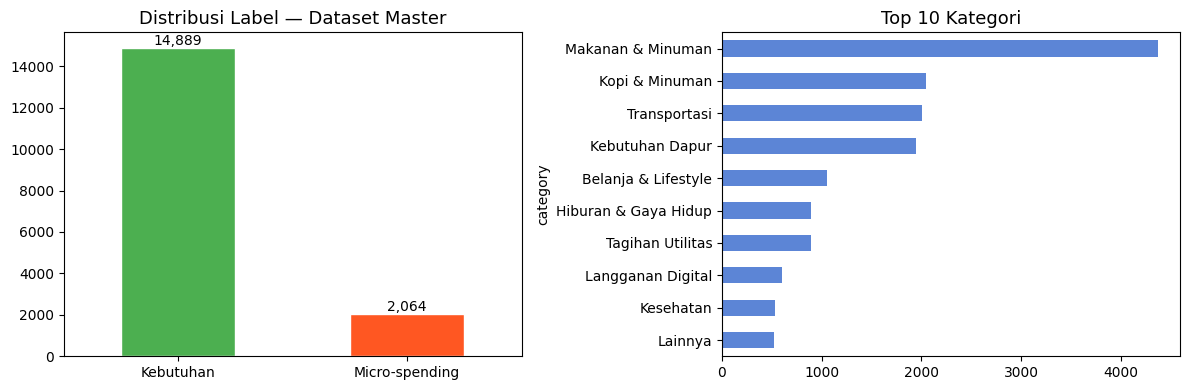

In [27]:
# ── Visualisasi distribusi label & kategori ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: Distribusi Label ──────────────────────────────
label_map = {0: 'Kebutuhan', 1: 'Micro-spending'}
label_series = df_master['label'].map(label_map)

label_counts = label_series.value_counts()

label_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#4CAF50', '#FF5722'],
    edgecolor='white'
)

axes[0].set_title('Distribusi Label — Dataset Master', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Annotasi jumlah
for i, v in enumerate(label_counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# ── Plot 2: Top Kategori ──────────────────────────────────
cat_counts = df_master['category'].value_counts().head(10)

cat_counts.plot(
    kind='barh',
    ax=axes[1],
    color='#5C85D6'
)

axes[1].set_title('Top 10 Kategori', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 💾 SECTION 7 — Export Dataset Master

Pada tahap ini, dataset final diekspor dan diarsipkan (*persisted*) ke dalam format `.csv` dengan nama `centsaver_master.csv`.

### 📦 Profil Dataset Final
Dataset *master* ini merupakan *single source of truth* (SSOT) yang telah melewati seluruh *pipeline* rekayasa data secara ketat. Karakteristik utama dataset ini meliputi:
- **Clean & Standardized:** Bebas dari *noise* mentah, duplikasi, dan memiliki skema tipe data (waktu, nominal, kategori) yang terstandardisasi.
- **Contextually Labeled:** Menggunakan label probabilistik (anti-*data leakage*) yang mencerminkan ketidakseimbangan natural (*real-world imbalanced prior*) dari perilaku finansial manusia.
- **Localized:** Diperkaya dengan varians data sintetis yang spesifik mengadopsi nama *merchant* dan daya beli Rupiah (IDR) di Indonesia.

### 🚀 Handoff (Langkah Selanjutnya)
Dataset ini sudah 100% siap untuk diserahkan pada proses *downstream* berikutnya:
- **Exploratory Data Analysis (DS2):** Untuk penggalian *insight* bisnis dan visualisasi pola kebiasaan *micro-spending*.
- **Model Development (AI Engineer):** Untuk pelatihan arsitektur *Deep Learning* multi-input tanpa risiko kebocoran data.

In [28]:
# ── Export Dataset Master ──────────────────────────────────


output_file = os.path.join(OUTPUT_PATH, 'centsaver_master_relabelling.csv')
df_master.to_csv(output_file, index=False)

print('✅ Dataset master berhasil disimpan!')
print(f'   Path   : {output_file}')
print(f'   Shape  : {df_master.shape}')
print(f'   Size   : {os.path.getsize(output_file) / 1024:.1f} KB')

print('\nDataset ini siap digunakan')


✅ Dataset master berhasil disimpan!
   Path   : data/processed/centsaver_master_relabelling.csv
   Shape  : (16953, 10)
   Size   : 1182.9 KB

Dataset ini siap digunakan


---
## 📖 SECTION 8 — Data Dictionary

Dokumentasi komprehensif mengenai struktur, tipe data, dan deskripsi dari setiap kolom pada dataset master `centsaver_master.csv`.

---

### 📦 Skema Dataset

| Kolom | Tipe Data | Deskripsi | Contoh Nilai |
|-------|-----------|-----------|--------------|
| `date` | `string` (YYYY-MM-DD) | Tanggal transaksi dilakukan. | `2024-03-15` |
| `description` | `string` | Nama *merchant*, *payment gateway*, atau deskripsi mentah transaksi. | `Kopi Kenangan`, `GoPay - GoFood` |
| `category` | `string` | Kategori transaksi (hasil *mapping* standardisasi taksonomi CentSaver). | `Kopi & Minuman`, `Tagihan Utilitas` |
| `amount` | `float` | Nominal transaksi riil dalam mata uang Rupiah (IDR). | `45000`, `120000` |
| `day_of_week` | `int` | Indeks hari dalam satu minggu (0=Senin, 6=Minggu). | `0`, `5` |
| `is_weekend` | `int` | Indikator akhir pekan (1 jika Sabtu/Minggu, 0 jika hari kerja). | `1`, `0` |
| `month` | `int` | Komponen bulan transaksi (1–12). | `3`, `12` |
| `year` | `int` | Komponen tahun transaksi. | `2024` |
| `label` | `int` | **Target Variable:** 1 = *Micro-spending* (impulsif), 0 = Kebutuhan (wajar). | `1`, `0` |
| `source` | `string` | Penanda asal dataset (*data lineage*) untuk *traceability*. | `dataset_1`, `synthetic_id` |

---

### ⚠️ MODELING GUIDELINES (ANTI-LEAKAGE)

> Kolom `category` merupakan fitur turunan (*derived feature*) yang dirancang **khusus untuk kebutuhan Exploratory Data Analysis (EDA) dan reporting**. 
>
> Untuk mencegah *Data Leakage*, kolom `category` **disarankan tidak digunakan** sebagai fitur input saat melatih model klasifikasi. Model AI harus dipaksa belajar mengekstraksi pola secara mandiri dan jujur dari kombinasi fitur asli: `description` (via NLP), `amount`, `day_of_week`, `is_weekend`, `month`, dan `year`.

---

### 📌 Taksonomi Kategori CentSaver

Meskipun pelabelan akhir menggunakan logika probabilitas kontekstual (bukan *hard-mapping* kaku), taksonomi di bawah ini merupakan *baseline* untuk membedakan tingkat risiko dari setiap pengeluaran:

#### 🔴 Kategori Rentan Micro-Spending (High-Risk)
Kategori ini memiliki peluang sangat tinggi untuk menjadi **Label 1**, terutama jika nominal transaksinya kecil dan terjadi di akhir pekan:

| Kategori | Cakupan Pengeluaran |
|----------|---------------------|
| Kopi & Minuman | Kopi, minuman kekinian, *bubble tea* |
| Makanan & Minuman | Restoran, *fast food*, *food delivery* |
| Hiburan & Gaya Hidup | Bioskop, karaoke, *game*, nongkrong |
| Belanja & Lifestyle | *Fashion*, aksesoris, belanja impulsif |
| Kecantikan & Perawatan | *Skincare*, kosmetik, salon, spa |
| Langganan Digital | Netflix, Spotify, YouTube Premium |
| Hobi & Olahraga | Aktivitas hobi dan olahraga non-esensial |
| Perjalanan | Liburan, *staycation*, tiket wisata |
| Lainnya | Pengeluaran non-esensial lainnya |

---

#### 🟢 Kategori Kebutuhan Esensial (Low-Risk)
Kategori ini secara mendasar diprioritaskan sebagai kebutuhan pokok (**Label 0**), karena merupakan pengeluaran wajib atau terencana:

| Kategori | Cakupan Pengeluaran |
|----------|---------------------|
| Kebutuhan Dapur | *Groceries*, bahan makanan mentah |
| Kebutuhan Rumah Tangga | Perlengkapan dan perawatan rumah |
| Sewa & Cicilan | Kos, kontrakan, cicilan aset |
| Tagihan Utilitas | Listrik, air, internet, pulsa wajib |
| Kesehatan | Obat-obatan, dokter, BPJS |
| Pendidikan | SPP, buku, kursus |
| Transportasi | Ojek *online*, bensin, transportasi umum |
| Keluarga & Sosial | Hadiah, acara keluarga, sumbangan |
| Administrasi | Biaya admin bank/platform |
| Elektronik | Perangkat kerja atau belajar |